# COMP 579 Assignment 3 - Question 3

Prepared by: Nicolas Smits

Presented to: Prof. Isabeau Premont Schwartz, Valliappan Chidambaram Adaikkappan

## Task 3 - Policy-Based Methods with Deep Neural Networks

In [1]:
# import gym
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from tqdm import tqdm
import glob

if not hasattr(np, 'float_'):
    np.float_ = np.float64

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

### 3.1 & 3.2 - REINFORCE & Actor-Critic with Deep NN Function Approximation & Initialisation

In [46]:
# Policy network class (for z(s) from REINFORCE algo's Boltzmann policy)
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
        self.apply(init_weights_He)
        # self.apply(init_weights_xavier)

    # forward pass through ReLU (no softmax here)
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        return self.fc3(x)  # return raw logits
    
class BaselineNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=256):
        super(BaselineNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.apply(init_weights_He)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
    
# Critic Network for Actor-Critic agent (for V(s) estimates)
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(CriticNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)
        self.apply(init_weights_He)
    
    # forward pass through ReLU and linear layer
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
    
def init_weights_He(layer):
    if hasattr(layer, 'weight') and layer.weight is not None:
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
    if hasattr(layer, 'bias') and layer.bias is not None:
        # Initialize biases to zero instead of using Xavier
        nn.init.zeros_(layer.bias)
        # nn.init.uniform_(layer.bias, -0.01, 0.01)

def init_weights_xavier(layer):
    if hasattr(layer, 'weight') and layer.weight is not None:
        nn.init.xavier_uniform_(layer.weight, gain=nn.init.calculate_gain('relu'))
    if hasattr(layer, 'bias') and layer.bias is not None:
        # Initialize biases to zero instead of using Xavier
        nn.init.zeros_(layer.bias)
        # nn.init.uniform_(layer.bias, -0.01, 0.01)

# for ALE/Assault-ram-v5 
def preprocess_state(state):
    """Normalize RAM states to [0,1]."""
    return np.array(state, dtype=np.float32) / 255.0

# Agent Scaffold Class
class Agent:
    def __init__(self, env_name, hidden_dim=128, lr=1e-3, gamma=0.99, temperature=1.0):
        self.env = gym.make(env_name)
        self.state_dim = self.env.observation_space.shape[0]
        self.action_dim = self.env.action_space.n
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.gamma = gamma
        self.temperature = temperature
    
    # select action
    # def select_action(self, state, policy_network):
    #     if not isinstance(state, torch.Tensor):
    #         state = torch.FloatTensor(state)
    #     if state.nelement() == 0:
    #         state = torch.FloatTensor(self.env.reset())
    #     state = state.unsqueeze(0)
    #     logits = policy_network(state)
    #     # Apply temperature scaling and softmax
    #     scaled_logits = logits / self.temperature
    #     action_probs = F.softmax(scaled_logits, dim=1)
    #     action = torch.multinomial(action_probs, num_samples=1).item()
    #     return action

    def select_action(self, state, policy_network):
        if not isinstance(state, torch.Tensor):
            state = torch.FloatTensor(state)
        # Only unsqueeze if state is 1D.
        if state.dim() == 1:
            state = state.unsqueeze(0)
        logits = policy_network(state)
        # Apply temperature scaling and softmax.
        scaled_logits = logits / self.temperature
        action_probs = F.softmax(scaled_logits, dim=1)
        action = torch.multinomial(action_probs, num_samples=1).item()
        return action

    # save the model
    def save_model(self, path):
        torch.save(self.policy_network.state_dict(), path)
    
    def load_model(self, path):
        self.policy_network.load_state_dict(torch.load(path))


# REINFORCE Agent
class ReinforceAgent(Agent):
    def __init__(self, env_name, hidden_dim=256, lr=1e-3, gamma=0.99, temperature=1.0, with_baseline=False):
        """
        If with_baseline=True, uses REINFORCE with baseline (advantage).
        If with_baseline=False, uses standard REINFORCE with raw returns.
        """
        super(ReinforceAgent, self).__init__(env_name, hidden_dim, lr, gamma, temperature)
        self.with_baseline = with_baseline

        # Policy network and optimizer
        self.policy_network = PolicyNetwork(self.state_dim, self.action_dim, hidden_dim=self.hidden_dim)
        self.policy_optimizer = optim.Adam(self.policy_network.parameters(), lr=self.lr)

        # If using a baseline, create a baseline network and optimizer
        if self.with_baseline:
            self.baseline_network = BaselineNetwork(self.state_dim, hidden_dim=self.hidden_dim)
            self.baseline_optimizer = optim.Adam(self.baseline_network.parameters(), lr=self.lr)


    # train the agent
    def train_one_episode(self, episode=0):
        state, _ = self.env.reset()
        if hasattr(self.env, "spec") and self.env.spec is not None and "ALE" in self.env.spec.id:
            state = preprocess_state(state)
        done = False
        trajectory = []
        episode_return = 0

        while not done:
            action = self.select_action(state, self.policy_network) # select action
            next_state, reward, terminated, truncated, info = self.env.step(action) # take action then observe reward and next state
            done = terminated or truncated
            trajectory.append((state, action, reward)) # store trajectory 
            if done:
                break
            state = next_state # next state
            if hasattr(self.env, "spec") and self.env.spec is not None and "ALE" in self.env.spec.id:
                state = preprocess_state(state)
            episode_return += reward

        # compute returns
        returns = []
        G = 0
        for _, _, reward in trajectory[::-1]:
            G = reward + self.gamma * G # discount return
            returns.insert(0, G)
        
        # Lists to store log probabilities and advantages.
        log_probs = []
        advantages = []
        baseline_loss = 0.0

        # Calculate log probabilities and advantages.
        for (state, action, _), G in zip(trajectory, returns):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            logits = self.policy_network(state_tensor)
            scaled_logits = logits / self.temperature
            action_probs = F.softmax(scaled_logits, dim=1)
            # Add a small constant for numerical stability when taking log.
            log_prob = torch.log(action_probs[0, action] + 1e-10)
            log_probs.append(log_prob)

            if self.with_baseline:
                V_s = self.baseline_network(state_tensor)
                advantage = G - V_s.item()
                baseline_loss += 0.5 * (V_s - G) ** 2
            else:
                advantage = G
            advantages.append(advantage)

        # Convert advantages to tensor and normalize them.
        advantages_tensor = torch.tensor(advantages, dtype=torch.float)
        if advantages_tensor.std() > 0:
            advantages_normalized = (advantages_tensor - advantages_tensor.mean()) / (advantages_tensor.std() + 1e-10)
        else:
            advantages_normalized = advantages_tensor

        # Compute the policy loss using the normalized advantages.
        policy_loss = 0.0
        for log_prob, adv in zip(log_probs, advantages_normalized):
            policy_loss += -log_prob * adv

        # Update the policy network with gradient clipping.
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_network.parameters(), max_norm=1.0)
        self.policy_optimizer.step()

        # If using a baseline, update it with gradient clipping as well.
        if self.with_baseline:
            self.baseline_optimizer.zero_grad()
            baseline_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.baseline_network.parameters(), max_norm=1.0)
            self.baseline_optimizer.step()

        return episode_return
            
    
# Actor-Critic Agent
class ActorCriticAgent(Agent):
    def __init__(self, env_name, hidden_dim=256, lr_actor=1e-3, lr_critic=1e-3, gamma=0.99, temperature=1.0):
        super(ActorCriticAgent, self).__init__(env_name, hidden_dim, lr_actor, gamma, temperature)
        self.policy_network = PolicyNetwork(self.state_dim, self.action_dim, self.hidden_dim)
        self.critic_network = CriticNetwork(self.state_dim, self.hidden_dim)
        self.policy_optimizer = optim.Adam(self.policy_network.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic_network.parameters(), lr=lr_critic)
        # print("Action dim:", self.action_dim)

    def train_one_episode(self, episode):
        # Reset the environment; state is expected as a NumPy array.
        state, _ = self.env.reset()
        if hasattr(self.env, "spec") and self.env.spec is not None and "ALE" in self.env.spec.id:
            state = preprocess_state(state)
        done = False
        episode_return = 0

        while not done:
            # Use select_action which expects a NumPy array or 1D tensor.
            action = self.select_action(state, self.policy_network)
            next_state, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated
            episode_return += reward

            if done:
                break

            if hasattr(self.env, "spec") and self.env.spec is not None and "ALE" in self.env.spec.id:
                state = preprocess_state(state)
                next_state = preprocess_state(next_state)
                
            # Convert the current and next states to tensors.
            state_tensor = to_tensor(state)
            # Only add a batch dimension if needed.
            if state_tensor.dim() == 1:
                state_tensor = state_tensor.unsqueeze(0)

            next_state_tensor = to_tensor(next_state)
            if next_state_tensor.dim() == 1:
                next_state_tensor = next_state_tensor.unsqueeze(0)

            # Also convert reward to a tensor.
            reward_tensor = to_tensor([reward])

            # --- Critic Update ---
            V_s = self.critic_network(state_tensor)
            V_next_s = self.critic_network(next_state_tensor)
            # Compute TD error (delta) and squeeze to ensure it's a scalar.
            delta = (reward_tensor + self.gamma * V_next_s - V_s).squeeze()
            critic_loss = delta.pow(2)

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.critic_network.parameters(), max_norm=1.0)
            self.critic_optimizer.step()

            # --- Policy (Actor) Update with Temperature Scaling ---
            logits = self.policy_network(state_tensor)
            scaled_logits = logits / self.temperature
            action_probs = F.softmax(scaled_logits, dim=1)
            # At this point, action_probs should have shape (1, action_dim)
            if action >= action_probs.shape[1]:
                raise IndexError(f"Action {action} is out of bounds for network output with shape {action_probs.shape}")
            action_prob = action_probs[0, action]
            policy_loss = -torch.log(action_prob + 1e-10) * delta.detach()

            self.policy_optimizer.zero_grad()
            policy_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy_network.parameters(), max_norm=1.0)
            self.policy_optimizer.step()

            state = next_state

        return episode_return

def train_fixed_temperature(agent_class, env_name, num_trials=50, num_episodes=1000, T_fixed=1.0):
    all_trial_returns = []
    for trial in range(1, num_trials + 1):
        print(f"\nTrial {trial}/{num_trials} on {env_name} (Fixed T = {T_fixed})")
        agent = agent_class(env_name, hidden_dim=128, lr=1e-3, gamma=0.99, temperature=T_fixed)
        trial_returns = []
        progress_bar = tqdm(range(num_episodes), desc=f"Trial {trial} Fixed T", leave=False)
        for episode in progress_bar:
            ret = agent.train_one_episode(episode)
            trial_returns.append(ret)
            progress_bar.set_postfix(ep=episode+1, ret=ret)
        all_trial_returns.append(trial_returns)
    return all_trial_returns

def train_decaying_temperature(agent_class, env_name, num_trials=50, num_episodes=1000, T0=1.0, T_min=0.1):
    all_trial_returns = []
    for trial in range(1, num_trials + 1):
        print(f"\nTrial {trial}/{num_trials} on {env_name} (Decaying T from {T0} to {T_min})")
        agent = agent_class(env_name, hidden_dim=128, lr=1e-3, gamma=0.99, temperature=T0)
        trial_returns = []
        progress_bar = tqdm(range(num_episodes), desc=f"Trial {trial} Decaying T", leave=False)
        for episode in progress_bar:
            # Linear decay of temperature.
            agent.temperature = max(T_min, T0 - (T0 - T_min) * (episode / num_episodes))
            ret = agent.train_one_episode(episode)
            trial_returns.append(ret)
            progress_bar.set_postfix(ep=episode+1, ret=ret, T=agent.temperature)
        all_trial_returns.append(trial_returns)
    return all_trial_returns

def to_tensor(x):
    if not isinstance(x, torch.Tensor):
        return torch.FloatTensor(x)
    return x

def train_agent_with_checkpoint(agent, env, num_episodes=1000, trial=1, config="Fixed",
                                base_folder="results_q3", checkpoint_interval=500,
                                T0=1.0, T_min=0.1):
    """
    Trains the agent with checkpointing and saves an .npy file of trial results.
    Folder structure: base_folder/env_name/{REINFORCE_T_const, REINFORCE_T_decay, AC_T_const, AC_T_decay}
    """
    try:
        env_name = env.unwrapped.spec.id
    except AttributeError:
        env_name = env.spec.id

    if "ALE/" in env_name:
        env_name = env_name.replace("ALE/", "")

    agent_type_full = agent.__class__.__name__
    if "Reinforce" in agent_type_full:
        agent_type = "Reinforce"
    elif "ActorCritic" in agent_type_full:
        agent_type = "ActorCritic"
    else:
        agent_type = agent_type_full

    folder_mapping = {
        ("Reinforce", "Fixed"): "REINFORCE_T_const",
        ("Reinforce", "Decaying"): "REINFORCE_T_decay",
        ("ActorCritic", "Fixed"): "AC_T_const",
        ("ActorCritic", "Decaying"): "AC_T_decay"
    }
    config_folder = folder_mapping.get((agent_type, config), config)
    checkpoint_folder = os.path.join(base_folder, env_name, config_folder)
    os.makedirs(checkpoint_folder, exist_ok=True)
    
    latest_cp_path = os.path.join(checkpoint_folder, f"latest_checkpoint{trial}.pt")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if os.path.exists(latest_cp_path):
        checkpoint = torch.load(latest_cp_path, map_location=device)
        starting_episode = checkpoint['episode'] + 1
        agent.policy_network.load_state_dict(checkpoint['policy_state_dict'])
        agent.policy_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        try:
            agent.critic_network.load_state_dict(checkpoint['critic_state_dict'])
            agent.critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])
        except Exception:
            pass
        total_rewards = checkpoint['total_rewards']
        tqdm.write(f"Resuming training from episode {starting_episode}")
    else:
        starting_episode = 0
        total_rewards = []
        tqdm.write("Starting new training run.")

    progress_bar = tqdm(range(starting_episode, num_episodes),
                        initial=starting_episode, total=num_episodes, desc="Episodes")

    for episode in progress_bar:
        if config == "Decaying":
            agent.temperature = max(T_min, T0 - (T0 - T_min) * (episode / num_episodes))
        episode_reward = agent.train_one_episode(episode)
        total_rewards.append(episode_reward)
        progress_bar.set_description(f"Ep {episode+1}: Reward = {episode_reward}, Temp = {agent.temperature:.3f}")

        if (episode + 1) % checkpoint_interval == 0:
            cp = {
                'episode': episode,
                'total_rewards': total_rewards,
                'policy_state_dict': agent.policy_network.state_dict(),
                'optimizer_state_dict': agent.policy_optimizer.state_dict()
            }
            try:
                cp['critic_state_dict'] = agent.critic_network.state_dict()
                cp['critic_optimizer_state_dict'] = agent.critic_optimizer.state_dict()
            except Exception:
                pass
            torch.save(cp, latest_cp_path)
            file_name = f"{env_name}_{agent_type}_{config}_trial{trial}_ep{episode+1}.pt"
            cp_path = os.path.join(checkpoint_folder, file_name)
            torch.save(cp, cp_path)
            # Save training results as .npy file
            npy_name = f"{env_name}_{agent_type}_{config}_trial{trial}.npy"
            npy_path = os.path.join(checkpoint_folder, npy_name)
            np.save(npy_path, np.array(total_rewards))
            tqdm.write(f"Checkpoint and npy saved at episode {episode+1}")

    agent.total_rewards = total_rewards

    if "ALE/" in env_name:
        print("ALE env detected.")
        env_name = env_name.replace("ALE/", "")
        npy_name = f"{env_name}_{agent_type}_{config}_trial{trial}.npy"
    else:
        npy_name = f"{env_name}_{agent_type}_{config}_trial{trial}.npy"

    npy_path = os.path.join(checkpoint_folder, npy_name)
    np.save(npy_path, np.array(total_rewards))
    return total_rewards

### 3.3 Training Algorithms with Different Temperature Schedules

Acrobot-v1 REINFORCE --> Testing for 1 Trial

In [20]:
env_name = "Acrobot-v1"
T_schedule = "Decaying"

env = gym.make(env_name)
agent = ReinforceAgent(env_name=env_name, hidden_dim=256, lr=1e-4, gamma=0.99, temperature=1.0, with_baseline=True)

# Use the decaying configuration.
rewards = train_agent_with_checkpoint(agent, env, num_episodes=1000, trial=1,
                                        config=T_schedule, base_folder="results_q3",
                                        checkpoint_interval=1500, T0=1.0, T_min=0.25)

Starting new training run.


Ep 1000: Reward = -75.0, Temp = 0.251: 100%|██████████| 1000/1000 [01:47<00:00,  9.29it/s]


In [ ]:
def plot_trial_returns(trial_returns, title="Returns over Episodes"):
    """
    Plot the returns averaged over trials with standard deviation shading.
    
    Parameters:
      trial_returns: list of lists (each inner list is the returns for one trial)
      title: title for the plot
    """
    # Convert the trial returns to a NumPy array.
    trial_returns = np.array(trial_returns)  # shape: (num_trials, num_episodes)
    
    # Compute mean and standard deviation across trials for each episode.
    mean_returns = np.mean(trial_returns, axis=0)
    std_returns = np.std(trial_returns, axis=0)
    episodes = np.arange(1, trial_returns.shape[1] + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(episodes, mean_returns, label="Mean Return", color="blue")
    plt.fill_between(episodes, mean_returns - std_returns, mean_returns + std_returns, 
                     color="blue", alpha=0.3, label="Std Dev")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title(title)
    plt.legend()
    plt.show()

plot_trial_returns([rewards], title="REINFORCE Decaying Temperature Returns")

Assault-ram-v5 REINFORCE --> Testing for 1 Trail

In [44]:
env_name = "ALE/Assault-ram-v5"
T_schedule = "Fixed"

env = gym.make(env_name, obs_type='ram')
agent = ReinforceAgent(env_name=env_name, hidden_dim=256, lr=1e-3, gamma=0.9, temperature=1.0, with_baseline=True)

# Use the decaying configuration.
rewards = train_agent_with_checkpoint(agent, env, num_episodes=1000, trial=1,
                                        config=T_schedule, base_folder="results_q3",
                                        checkpoint_interval=1500, T0=1.0, T_min=0.25)

Starting new training run.


Ep 1000: Reward = 378.0, Temp = 1.000: 100%|██████████| 1000/1000 [07:22<00:00,  2.26it/s]


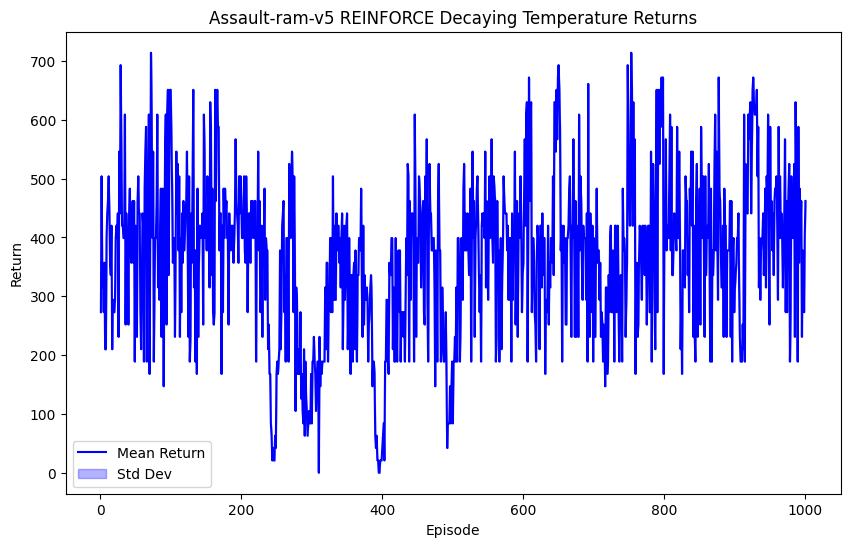

In [40]:
plot_trial_returns([rewards], title="Assault-ram-v5 REINFORCE Decaying Temperature Returns")

AC Acrobot-v1 --> Testing for 1 Trail

In [132]:
env_name = "Acrobot-v1"
T_schedule = "Decaying"

env = gym.make(env_name)
agent = ActorCriticAgent(env_name=env_name, hidden_dim=256, lr_actor=1e-5, lr_critic=1e-4, gamma=0.99)

# Use the decaying configuration.
rewards = train_agent_with_checkpoint(agent, env, num_episodes=1000, trial=1,
                                        config=T_schedule, base_folder="results_q3",
                                        checkpoint_interval=1500, T0=1.0, T_min=0.25)

Action dim: 3
Starting new training run.


Ep 1000: Reward = -79.0, Temp = 0.251: 100%|██████████| 1000/1000 [04:48<00:00,  3.47it/s]


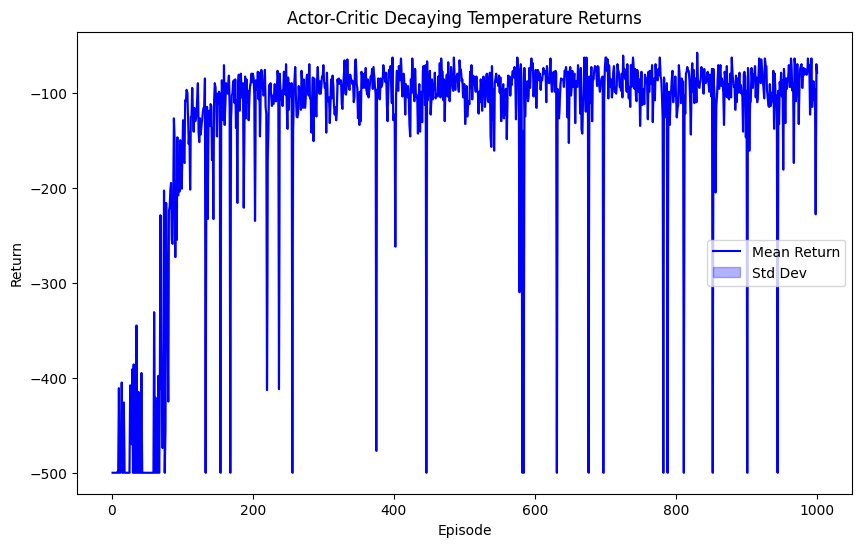

In [ ]:
plot_trial_returns([rewards], title="Actor-Critic Decaying Temperature Returns")

AC Assault-ram-v5 --> Testing for 1 Trial

In [17]:
env_name = "ALE/Assault-ram-v5"
T_schedule = "Decaying"

env = gym.make(env_name)
agent = ActorCriticAgent(env_name=env_name, hidden_dim=256, lr_actor=1e-5, lr_critic=1e-4, gamma=0.99)

# Use the decaying configuration.
rewards = train_agent_with_checkpoint(agent, env, num_episodes=1000, trial=1,
                                        config=T_schedule, base_folder="results_q3",
                                        checkpoint_interval=1500, T0=1.0, T_min=0.25)

Starting new training run.


Ep 8: Reward = 252.0, Temp = 0.995:   1%|          | 8/1000 [00:14<29:54,  1.81s/it]


KeyboardInterrupt: 

In [7]:
plot_trial_returns([rewards], title="Actor-Critic Decaying Temperature Returns")

NameError: name 'rewards' is not defined

In [48]:
# Overall training loop with checkpointing and saving for multiple trials for multiple trials.

# best combination of hyperparameters for each environment from single trial runs
experiments = [
    # REINFORCE on Acrobot-v1
    {
        'agent_class': ReinforceAgent,
        'env_name': "Acrobot-v1",
        'config': "Decaying",
        'lr': 1e-4,
        'gamma': 0.99,
        'temperature': 1.0,
        'with_baseline': True,
        'schedule': 'Decaying'
    },
    {
        'agent_class': ReinforceAgent,
        'env_name': "Acrobot-v1",
        'config': "Fixed",
        'lr': 1e-4,
        'gamma': 0.99,
        'temperature': 1.0,
        'with_baseline': True,
        'schedule': 'Fixed'
    },
    # REINFORCE on ALE/Assault-ram-v5
    {
        'agent_class': ReinforceAgent,
        'env_name': "ALE/Assault-ram-v5",
        'config': "Decaying",
        'lr': 1e-3,
        'gamma': 0.9,
        'temperature': 1.0,
        'with_baseline': True,
        'schedule': 'Decaying'
    },
    {
        'agent_class': ReinforceAgent,
        'env_name': "ALE/Assault-ram-v5",
        'config': "Fixed",
        'lr': 1e-3,
        'gamma': 0.9,
        'temperature': 1.0,
        'with_baseline': True,
        'schedule': 'Fixed'
    },
    # Actor-Critic on Acrobot-v1
    {
        'agent_class': ActorCriticAgent,
        'env_name': "Acrobot-v1",
        'config': "Decaying",
        'lr_actor': 1e-5,
        'lr_critic': 1e-4,
        'gamma': 0.99,
        'temperature': 1.0,
        'schedule': 'Decaying'
    },
    {
        'agent_class': ActorCriticAgent,
        'env_name': "Acrobot-v1",
        'config': "Fixed",
        'lr_actor': 1e-5,
        'lr_critic': 1e-4,
        'gamma': 0.99,
        'temperature': 1.0,
        'schedule': 'Fixed'
    },
    # Actor-Critic on ALE/Assault-ram-v5
    {
        'agent_class': ActorCriticAgent,
        'env_name': "ALE/Assault-ram-v5",
        'config': "Decaying",
        'lr_actor': 1e-4,
        'lr_critic': 1e-3,
        'gamma': 0.99,
        'temperature': 1.0,
        'schedule': 'Decaying'
    },
    {
        'agent_class': ActorCriticAgent,
        'env_name': "ALE/Assault-ram-v5",
        'config': "Fixed",
        'lr_actor': 1e-4,
        'lr_critic': 1e-3,
        'gamma': 0.99,
        'temperature': 1.0,
        'schedule': 'Fixed'
    }
]

# Hyperparameters for the overall training loop.
num_trials = 10
num_episodes = 1000
checkpoint_interval = 500
T0 = 1.0
T_min = 0.25

# Loop over experiments.
for exp in experiments:
    print("\n========================================")
    print(f"Starting experiment: {exp}")
    agent_class = exp['agent_class']
    env_name_full = exp['env_name']
    config = exp['config']  # "Fixed" or "Decaying"

    # For folder naming, remove the "ALE/" prefix if present.
    if "ALE/" in env_name_full:
        env_name = env_name_full.replace("ALE/", "")
    else:
        env_name = env_name_full
    print(f"Environment: {env_name}")
    # Create the environment.
    if "ALE" in env_name_full:
        # print(env_name_full)
        env = gym.make(env_name_full, obs_type='ram')
    else:
        # print(env_name_full)
        env = gym.make(env_name_full)
    
    # Set up folder mapping for saving files.
    folder_mapping = {
        ("Reinforce", "Fixed"): "REINFORCE_T_const",
        ("Reinforce", "Decaying"): "REINFORCE_T_decay",
        ("ActorCritic", "Fixed"): "AC_T_const",
        ("ActorCritic", "Decaying"): "AC_T_decay"
    }
    agent_type = "Reinforce" if "Reinforce" in agent_class.__name__ else "ActorCritic"
    config_folder = folder_mapping.get((agent_type, config), config)
    save_folder = os.path.join("results_q3", env_name, config_folder)
    os.makedirs(save_folder, exist_ok=True)
    
    # Loop over trials.
    for trial in range(1, num_trials + 1):
        print(f"\n--- Trial {trial}/{num_trials} for {env_name} {agent_type} {config} ---")
        # Instantiate the agent with proper hyperparameters.
        if agent_class == ReinforceAgent:
            agent = agent_class(
                env_name=env_name_full,
                hidden_dim=256,
                lr=exp['lr'],
                gamma=exp['gamma'],
                temperature=exp['temperature'],
                with_baseline=exp.get('with_baseline', False)
            )
        elif agent_class == ActorCriticAgent:
            agent = agent_class(
                env_name=env_name_full,
                hidden_dim=256,
                lr_actor=exp['lr_actor'],
                lr_critic=exp['lr_critic'],
                gamma=exp['gamma'],
                temperature=exp['temperature']
            )
        else:
            raise ValueError("Unknown agent class")
        
        # Use the checkpointing training function for each trial.
        trial_results = train_agent_with_checkpoint(
            agent, env, num_episodes=num_episodes, trial=trial, config=exp['schedule'],
            base_folder="results_q3", checkpoint_interval=checkpoint_interval, T0=T0, T_min=T_min
        )

        # print(trial_results)
        
        # Save trial results as an .npy file with a trial-specific name.
        if "ALE/" in env_name:
            save_env_name = env_name.replace("ALE/", "")
        else:
            save_env_name = env_name
        npy_name = f"{save_env_name}_{agent_type}_{config}_trial{trial}.npy"
        npy_path = os.path.join(save_folder, npy_name)
        np.save(npy_path, np.array(trial_results))
        print(f"Saved trial {trial} results to {npy_path}")

/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_69233/2963317090.py:358: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_cp_path, map


Starting experiment: {'agent_class': <class '__main__.ReinforceAgent'>, 'env_name': 'Acrobot-v1', 'config': 'Decaying', 'lr': 0.0001, 'gamma': 0.99, 'temperature': 1.0, 'with_baseline': True, 'schedule': 'Decaying'}
Environment: Acrobot-v1

--- Trial 1/10 for Acrobot-v1 Reinforce Decaying ---
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


[-336.0, -249.0, -181.0, -197.0, -206.0, -261.0, -245.0, -189.0, -275.0, -180.0, -232.0, -194.0, -219.0, -197.0, -273.0, -196.0, -249.0, -171.0, -161.0, -226.0, -226.0, -222.0, -233.0, -190.0, -207.0, -243.0, -263.0, -167.0, -180.0, -181.0, -187.0, -203.0, -203.0, -225.0, -243.0, -173.0, -288.0, -165.0, -151.0, -243.0, -174.0, -191.0, -203.0, -195.0, -256.0, -157.0, -184.0, -160.0, -248.0, -170.0, -164.0, -188.0, -180.0, -203.0, -176.0, -214.0, -153.0, -202.0, -180.0, -165.0, -196.0, -211.0, -171.0, -190.0, -231.0, -226.0, -145.0, -181.0, -223.0, -179.0, -218.0, -169.0, -179.0, -164.0, -198.0, -209.0, -179.0, -176.0, -149.0, -187.0, -170.0, -200.0, -196.0, -196.0, -170.0, -199.0, -179.0, -173.0, -199.0, -188.0, -226.0, -179.0, -241.0, -190.0, -180.0, -208.0, -249.0, -171.0, -170.0, -175.0, -153.0, -201.0, -143.0, -184.0, -162.0, -189.0, -174.0, -166.0, -155.0, -181.0, -217.0, -203.0, -179.0, -219.0, -140.0, -170.0, -237.0, -176.0, -189.0, -180.0, -169.0, -235.0, -176.0, -179.0, -190.0,

Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


...

Checkpoint and npy saved at episode 1000
[378.0, 84.0, 168.0, 84.0, 42.0, 21.0, 0.0, 21.0, 0.0, 0.0, 0.0, 0.0, 84.0, 126.0, 273.0, 210.0, 168.0, 189.0, 168.0, 189.0, 63.0, 294.0, 189.0, 231.0, 378.0, 147.0, 273.0, 168.0, 420.0, 294.0, 189.0, 168.0, 189.0, 147.0, 189.0, 126.0, 294.0, 189.0, 147.0, 105.0, 189.0, 273.0, 273.0, 210.0, 168.0, 0.0, 126.0, 84.0, 147.0, 126.0, 63.0, 84.0, 84.0, 189.0, 42.0, 21.0, 21.0, 0.0, 0.0, 21.0, 0.0, 0.0, 21.0, 0.0, 21.0, 0.0, 0.0, 21.0, 0.0, 21.0, 63.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 168.0, 210.0, 189.0, 0.0, 105.0, 189.0, 210.0, 42.0, 84.0, 84.0, 84.0, 105.0, 42.0, 21.0, 21.0, 0.0, 0.0, 0.0, 0.0, 63.0, 0.0, 0.0, 0.0, 0.0, 0.0, 147.0, 147.0, 105.0, 0.0, 21.0, 0.0, 21.0, 0.0, 0.0, 21.0, 0.0, 0.0, 0.0, 42.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 84.0, 0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 42.0, 0.0, 0.0, 0.0, 0.0, 0.0, 336.0, 42.0, 0.0, 0.0, 0.0, 0.0, 105.0, 0.0, 0.0, 42.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 168.0, 168.0, 105.0, 42.0, 21.0, 0.0, 0.0, 

Ep 500: Reward = 168.0, Temp = 1.000:  50%|█████     | 500/1000 [14:42<10:42,  1.29s/it]

Checkpoint and npy saved at episode 500


Ep 1000: Reward = 378.0, Temp = 1.000: 100%|██████████| 1000/1000 [27:28<00:00,  1.65s/it]

Checkpoint and npy saved at episode 1000
[336.0, 189.0, 21.0, 0.0, 0.0, 0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 252.0, 168.0, 231.0, 231.0, 84.0, 273.0, 168.0, 336.0, 315.0, 399.0, 399.0, 168.0, 378.0, 399.0, 525.0, 189.0, 378.0, 441.0, 525.0, 546.0, 378.0, 189.0, 588.0, 357.0, 273.0, 189.0, 378.0, 357.0, 231.0, 273.0, 462.0, 231.0, 420.0, 273.0, 210.0, 609.0, 420.0, 420.0, 231.0, 483.0, 483.0, 504.0, 420.0, 231.0, 399.0, 210.0, 420.0, 609.0, 399.0, 420.0, 189.0, 378.0, 525.0, 525.0, 441.0, 525.0, 231.0, 231.0, 231.0, 378.0, 294.0, 399.0, 420.0, 504.0, 483.0, 378.0, 441.0, 399.0, 546.0, 399.0, 441.0, 273.0, 441.0, 462.0, 231.0, 546.0, 189.0, 483.0, 504.0, 315.0, 399.0, 483.0, 231.0, 399.0, 525.0, 441.0, 189.0, 378.0, 504.0, 441.0, 399.0, 273.0, 441.0, 441.0, 441.0, 378.0, 399.0, 441.0, 462.0, 378.0, 378.0, 231.0, 504.0, 483.0, 231.0, 441.0, 357.0, 441.0, 231.0, 399.0, 441.0, 189.0, 378.0, 168.0, 462.0, 189.0, 357.0, 294.0, 399.0, 504.0

### 3.4 - Plotting

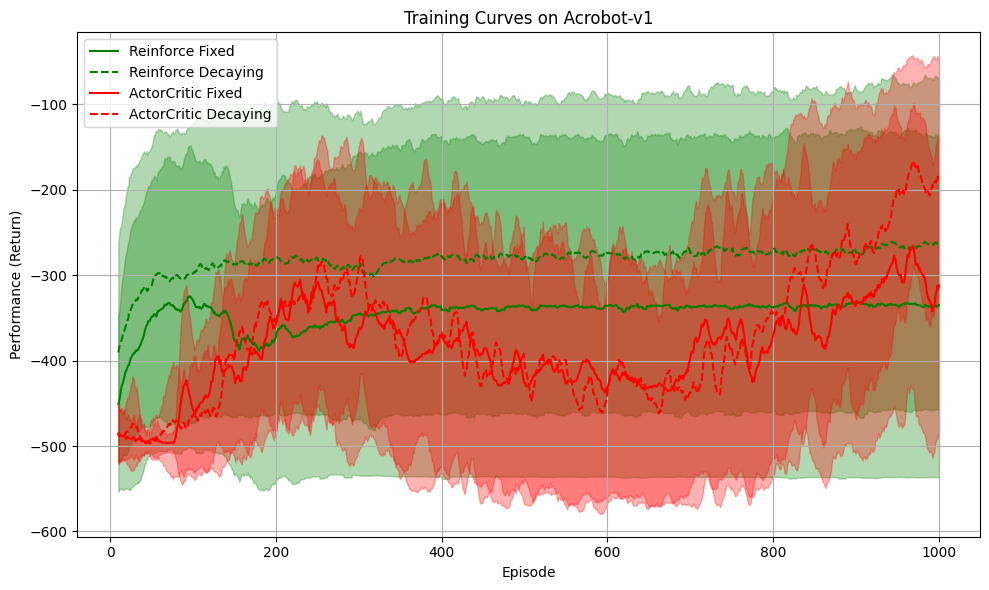

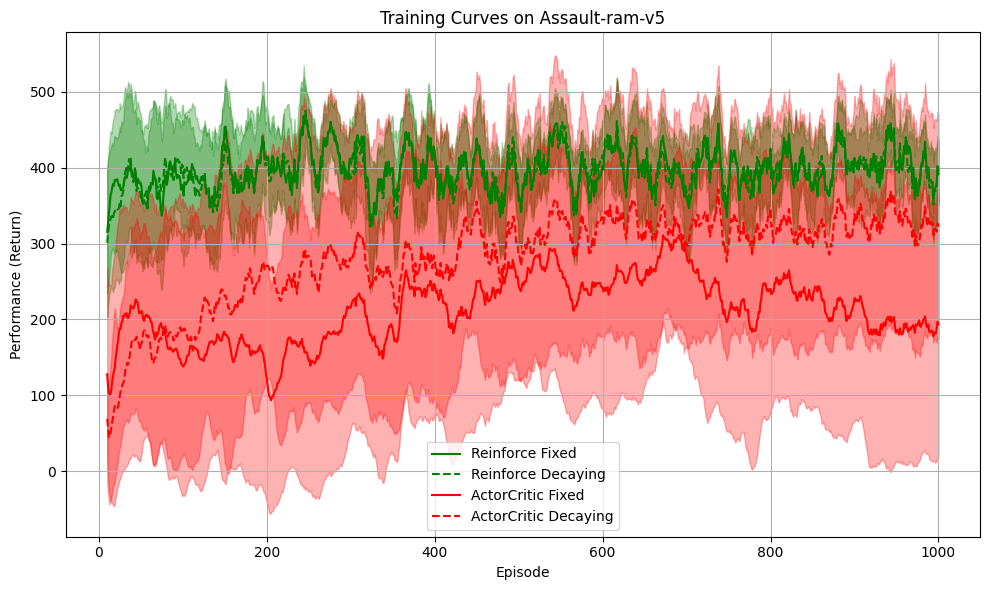

In [49]:
# smoothing function to reduce variance for plotting
def smooth_curve(data, window_size=50):
    window = np.ones(window_size) / window_size
    return np.convolve(data, window, mode='valid')

# helper function to load all trials from a folder for a given experiment.
def load_trials(env_name, config_folder, agent_type, config, base_folder="results_q3"):
    # Construct folder path: base_folder/env_name/config_folder
    folder = os.path.join(base_folder, env_name, config_folder)
    pattern = os.path.join(folder, f"{env_name}_{agent_type}_{config}_trial*.npy")
    file_list = sorted(glob.glob(pattern))
    # print(f"Number of files found: {len(file_list)}")
    if not file_list:
        print(f"No files found for pattern: {pattern}")
        return None
    # Each file is assumed to contain a 1D array (episode returns)
    trials = [np.load(f) for f in file_list]
    return np.array(trials)  # shape: (num_trials, num_episodes)

# Mapping from (agent type, schedule) to folder name
folder_mapping = {
    ("Reinforce", "Fixed"): "REINFORCE_T_const",
    ("Reinforce", "Decaying"): "REINFORCE_T_decay",
    ("ActorCritic", "Fixed"): "AC_T_const",
    ("ActorCritic", "Decaying"): "AC_T_decay"
}

def plot_env_results(env_name, smoothing=True):
    plt.figure(figsize=(10,6))
    
    smooth_window = 10  # adjust smoothing window as needed
    
    # Plot REINFORCE curves (green)
    for schedule in ["Fixed", "Decaying"]:
        agent_type = "Reinforce"
        config_folder = folder_mapping[(agent_type, schedule)]
        data = load_trials(env_name, config_folder, agent_type, schedule)
        if data is None:
            continue
        mean_curve = data.mean(axis=0)
        std_curve = data.std(axis=0)
        if len(mean_curve) >= smooth_window and smoothing:
            mean_curve = smooth_curve(mean_curve, window_size=smooth_window)
            std_curve = smooth_curve(std_curve, window_size=smooth_window)
            episodes = np.arange(smooth_window, len(data[0]) + 1)
        else:
            episodes = np.arange(1, len(mean_curve) + 1)
        linestyle = '-' if schedule == "Fixed" else '--'
        plt.plot(episodes, mean_curve, color='green', linestyle=linestyle, label=f"Reinforce {schedule}")
        plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, color='green', alpha=0.3)
    
    # Plot Actor-Critic curves (red)
    for schedule in ["Fixed", "Decaying"]:
        agent_type = "ActorCritic"
        config_folder = folder_mapping[(agent_type, schedule)]
        data = load_trials(env_name, config_folder, agent_type, schedule)
        if data is None:
            continue
        mean_curve = data.mean(axis=0)
        std_curve = data.std(axis=0)
        if len(mean_curve) >= smooth_window and smoothing:
            mean_curve = smooth_curve(mean_curve, window_size=smooth_window)
            std_curve = smooth_curve(std_curve, window_size=smooth_window)
            episodes = np.arange(smooth_window, len(data[0]) + 1)
        else:
            episodes = np.arange(1, len(mean_curve) + 1)
        linestyle = '-' if schedule == "Fixed" else '--'
        plt.plot(episodes, mean_curve, color='red', linestyle=linestyle, label=f"ActorCritic {schedule}")
        plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, color='red', alpha=0.3)
    
    plt.xlabel("Episode")
    plt.ylabel("Performance (Return)")
    plt.title(f"Training Curves on {env_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for each environment.
plot_env_results("Acrobot-v1", smoothing=True)
plot_env_results("Assault-ram-v5", smoothing=True)

#### Plot Explainations

##### Acrobot-v1:

In the Acrobot-v1 environment, REINFORCE outperforms Actor-Critic (AC) over most of the episodes, exhibiting both faster convergence and more stable performance. The learning profile of REINFORCE show fast and steady convergence to the fixed/decaying temperature schedule's ultimate performance, with the fixed profile showing one fluctuation of around 50 at the 150-200 episode mark, likely due to the more consistent exploration leading to briefly lower rewards. Overall however, REINFORCE with a decaying schedule performs the best out of the RL algorithms implemented, showing stable and consistently intermediate rewards (around -300). This improved learning behavior could be attributed to either a too exploratory or too greedy temperature value in the fixed case, hindering optimal convergence compared to a decaying schedule which shifts from exploration to exploitation more effectively. Alternatively, Acrobot-v1 can benefit from a changing exploration strategy because the optimal control sequence may not be apparent early on. A decaying schedule allows the policy to refine its behavior gradually, leading to improved performance over a fixed schedule that cannot adapt as the agent’s knowledge of the environment grows.

Analyzing the training rewards for individual trials show significant variation, with some runs immediately learning and yielding high rewards (e.g. around -100 for decaying REINFORCE), while others struggle to learn initially or at all, resulting in rewards of zero. Thus, when trial runs are averaged, an overall lower reward is observed (e.g.around -300 for decaying REINFORCE), reflected in the huge standard deviation (and thus variance) seen for primarily REINFORCE but also AC to a lesser extent. See the individual trial results above compared to the overall results. This high variance could be due to REINFORCE using complete episode returns to update the policy which can vary significantly from episode to episode—especially in environments with delayed rewards or sparse signals like Acrobot-v1. To mitigate the high variance a baseline network was implemented, however the problem persisted. Further hyperparameter variation and testing could have been conducted to reduce this further.

In Acrobot-v1, the AC algorithm generally performs worse and shows less stable convergence than REINFORCE though it does intermittently outperform the former. The interplay between the actor and critic introduces its own dynamics. Early on, the critic might not be very accurate, allowing the actor to learn rapidly and sometimes outperform REINFORCE. Over time, as the critic’s estimates adjust, the balance can shift—leading to periods where the actor-critic underperforms. After further training (e.g., after episode 900), the critic might finally provide sufficiently accurate signals for the actor to leverage, resulting in another performance boost. This cyclical behavior can explain why the actor-critic implementation sometimes shows lower variance overall but exhibits larger long-term fluctuations in performance. This was somewhat mitigated by different learning rates between the actor (1e-4) and the critic (1e-3), though the effect is still present. Conversely, the temperature schedule seemed to have little effect on the AC implementation in the Acrobot-v1 environment.


##### Assault-ram-v5:

In the Assault-ram-v5 environment, the REINFORCE algorithm outperformed the AC implementation again while the effect of the temperature schedules was reduced for REINFORCE but increased for AC. One reason is that REINFORCE, which relies on full-episode returns, does not introduce bias from a learned value function; it may have higher variance in principle, but in this environment, where rewards can appear relatively quickly, that variance does not severely hinder learning. By contrast, Actor-Critic methods reduce variance by incorporating a critic, yet can introduce bias if the critic’s value estimates are inaccurate or poorly tuned. This bias can lead to suboptimal updates and cause the Actor-Critic approach to learn more slowly or oscillate between strategies.

Additionally, REINFORCE shows very similar performance under both fixed and decaying temperature schedules, likely because it rapidly discovers beneficial actions and consistently reinforces them, rendering the precise exploration schedule less critical. In other words, once REINFORCE finds a good strategy, it keeps sampling those actions frequently enough to improve, regardless of whether the temperature is gradually decaying or held constant at a reasonable level.

Meanwhile, Actor-Critic performs worse overall but benefits more visibly from a decaying schedule. Early in training, a higher temperature fosters broader exploration, helping the critic observe a more varied range of states. As the temperature decreases, the policy can exploit the critic’s (hopefully) improved estimates. Although this decaying approach outperforms a fixed schedule in the Actor-Critic case, it still lags behind REINFORCE, since any inaccuracies or instabilities in the critic’s learning process can degrade performance over the course of training. Consequently, while the decaying schedule mitigates some exploration issues, the combination of bias from the critic and the demands of the environment keep the Actor-Critic methods below REINFORCE’s performance.